# Comparación de modelos de regresión — California Housing

Este notebook compara cuatro modelos para estimar el valor medio de viviendas:

1. **Regresión lineal**.
2. **Regresión polinomial** de grado 3.
3. **Regresión logarítmica**.
4. **Árbol de decisión para regresión**.

Se utiliza `MedInc` (ingreso medio del sector) para predecir `MedHouseVal` (valor medio de la vivienda). Trabajar con una variable explicativa permite visualizar directamente las líneas o curvas de estimación.

La unidad de `MedHouseVal` es aproximadamente **100.000 dólares**. Por ejemplo, un valor objetivo de `2.5` representa cerca de USD 250.000.

## 1. Instalación

Ejecuta esta celda si `scikit-learn` todavía no está instalado. California Housing se descarga la primera vez y luego queda almacenado en caché.

In [16]:
%pip install -q scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Librerías y configuración

In [17]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, FunctionTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
plt.style.use("seaborn-v0_8-whitegrid")


## 3. Cargar California Housing

La base contiene información de sectores censales de California. La primera descarga puede tardar algunos minutos dependiendo de la conexión.

In [18]:
print("Cargando California Housing...")
start = time.time()
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

print(f"Carga terminada en {time.time() - start:.2f} segundos")
print("Dimensiones:", df.shape)
print("Variables:", list(df.columns))
print("\nValores faltantes:", int(df.isna().sum().sum()))
display(df.head())


Cargando California Housing...
Carga terminada en 0.02 segundos
Dimensiones: (20640, 9)
Variables: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Valores faltantes: 0


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 4. Análisis de las variables seleccionadas

- `MedInc`: ingreso medio expresado en decenas de miles de dólares.
- `MedHouseVal`: valor medio de las viviendas en cientos de miles de dólares.

La dispersión también permite observar que existe un límite superior en el objetivo cercano a 5.

          MedInc  MedHouseVal
count  20640.000    20640.000
mean       3.871        2.069
std        1.900        1.154
min        0.500        0.150
25%        2.563        1.196
50%        3.535        1.797
75%        4.743        2.647
max       15.000        5.000


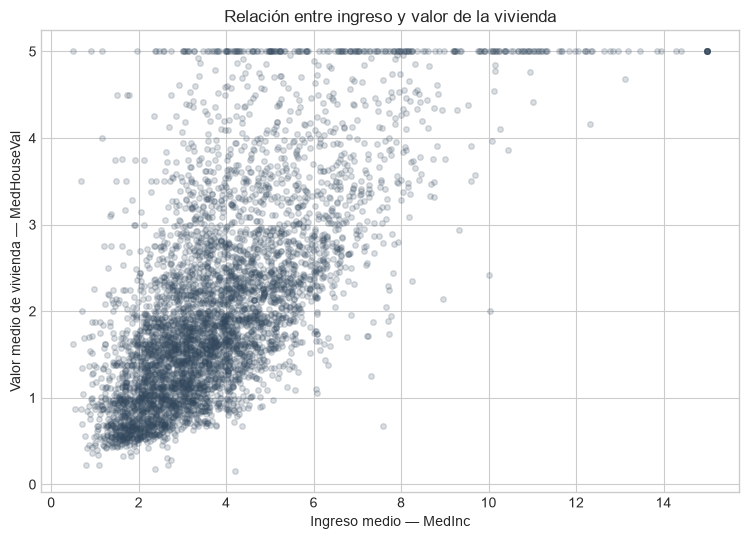

In [19]:
X = df[["MedInc"]].to_numpy()
y = df["MedHouseVal"].to_numpy()

print(df[["MedInc", "MedHouseVal"]].describe().round(3))

sample = df.sample(n=min(5000, len(df)), random_state=SEED)
plt.figure(figsize=(9, 6))
plt.scatter(sample["MedInc"], sample["MedHouseVal"],
            alpha=0.18, s=16, color="#34495e")
plt.xlabel("Ingreso medio — MedInc")
plt.ylabel("Valor medio de vivienda — MedHouseVal")
plt.title("Relación entre ingreso y valor de la vivienda")
plt.show()


## 5. División de entrenamiento y prueba

Se reserva 30 % de los datos para evaluar predicciones nuevas. La validación cruzada se realizará solamente sobre el conjunto de entrenamiento para mantener el test como evaluación final independiente.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
)

print(f"Entrenamiento: {len(X_train):,} registros ({len(X_train)/len(X):.0%})")
print(f"Prueba:        {len(X_test):,} registros ({len(X_test)/len(X):.0%})")


Entrenamiento: 14,448 registros (70%)
Prueba:        6,192 registros (30%)


## 6. Definición de modelos

### Lineal

$$\hat y=\beta_0+\beta_1x$$

### Polinomial

$$\hat y=\beta_0+\beta_1x+\beta_2x^2+\beta_3x^3$$

### Logarítmico

$$\hat y=\beta_0+\beta_1\log(1+x)$$

### Árbol de decisión

Divide el rango de ingresos en regiones y asigna una estimación constante a cada región. Se limita la profundidad para controlar el sobreajuste.

In [21]:
models = {
    "Lineal": Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression()),
    ]),
    "Polinomial (grado 3)": Pipeline([
        ("polynomial", PolynomialFeatures(degree=3, include_bias=False)),
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression()),
    ]),
    "Logarítmica": Pipeline([
        ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression()),
    ]),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        min_samples_leaf=40,
        random_state=SEED,
    ),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} entrenado")


Lineal entrenado
Polinomial (grado 3) entrenado
Logarítmica entrenado
Decision Tree entrenado


## 7. Métricas sobre el conjunto de prueba

- **MAE**: error absoluto medio; menor es mejor.
- **RMSE**: penaliza con mayor fuerza los errores grandes; menor es mejor.
- **R²**: proporción de variabilidad explicada; mayor es mejor.

MAE y RMSE están expresados en unidades de 100.000 dólares.

In [22]:
test_predictions = {}
test_rows = []

for name, model in models.items():
    prediction = model.predict(X_test)
    test_predictions[name] = prediction
    test_rows.append({
        "Modelo": name,
        "MAE": mean_absolute_error(y_test, prediction),
        "RMSE": np.sqrt(mean_squared_error(y_test, prediction)),
        "R²": r2_score(y_test, prediction),
    })

test_metrics = pd.DataFrame(test_rows).set_index("Modelo")
display(test_metrics.round(4))

best_test_model = test_metrics["RMSE"].idxmin()
print(f"Menor RMSE en test: {best_test_model}")


,MAE,RMSE,R²
Modelo,,,
Lineal,0.6232,0.8317,0.4729
Polinomial (grado 3),0.6155,0.8239,0.4828
Logarítmica,0.6462,0.8492,0.4506
Decision Tree,0.6149,0.8245,0.4821


Menor RMSE en test: Polinomial (grado 3)


## 8. Validación cruzada de 5 pliegues

En cada pliegue se entrena con 80 % del conjunto de entrenamiento y se valida con el 20 % restante. El proceso se repite cinco veces usando particiones diferentes.

Se reportan media y desviación estándar. Una desviación pequeña indica resultados estables entre particiones.

In [23]:
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {
    "MAE": "neg_mean_absolute_error",
    "MSE": "neg_mean_squared_error",
    "R2": "r2",
}

cv_rows = []
cv_details = {}

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )
    mae_scores = -scores["test_MAE"]
    rmse_scores = np.sqrt(-scores["test_MSE"])
    r2_scores = scores["test_R2"]
    cv_details[name] = {"MAE": mae_scores, "RMSE": rmse_scores, "R²": r2_scores}

    cv_rows.append({
        "Modelo": name,
        "MAE media": mae_scores.mean(),
        "MAE std": mae_scores.std(),
        "RMSE media": rmse_scores.mean(),
        "RMSE std": rmse_scores.std(),
        "R² medio": r2_scores.mean(),
        "R² std": r2_scores.std(),
    })

cv_metrics = pd.DataFrame(cv_rows).set_index("Modelo")
display(cv_metrics.round(4))


,MAE media,MAE std,RMSE media,RMSE std,R² medio,R² std
Modelo,,,,,,
Lineal,0.6272,0.0101,0.8397,0.0165,0.4729,0.0277
Polinomial (grado 3),0.6169,0.0105,0.8286,0.0183,0.4866,0.0292
Logarítmica,0.6541,0.0127,0.8600,0.0177,0.4471,0.0294
Decision Tree,0.6164,0.0100,0.8294,0.0190,0.4857,0.0287


### Resultados de cada pliegue

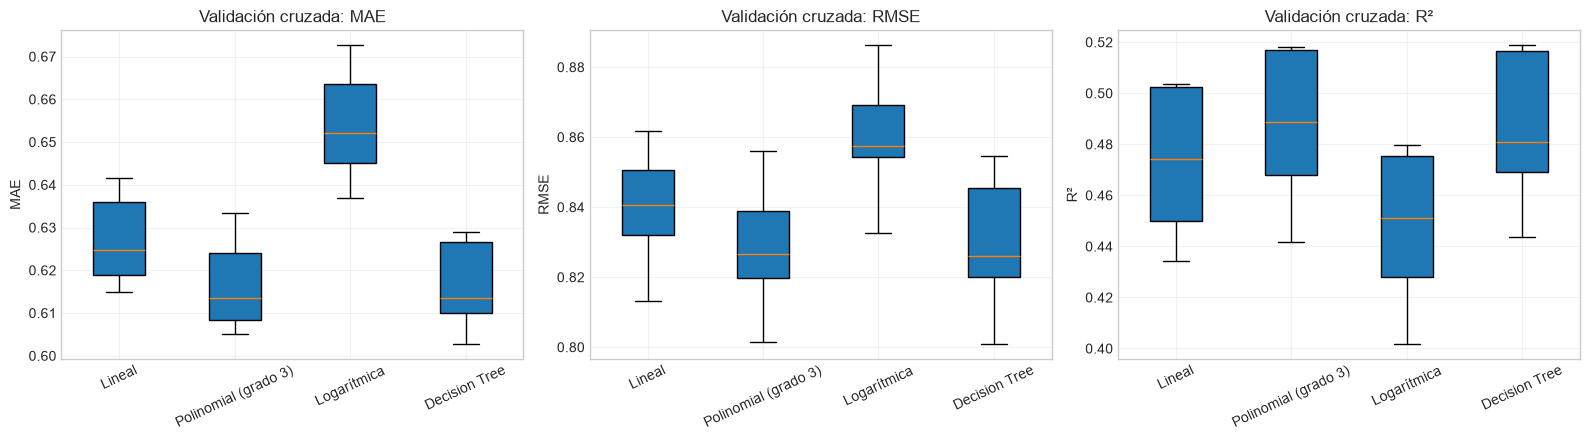

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, metric in zip(axes, ["MAE", "RMSE", "R²"]):
    values = [cv_details[name][metric] for name in models]
    ax.boxplot(values, tick_labels=list(models), patch_artist=True)
    ax.set_title(f"Validación cruzada: {metric}")
    ax.tick_params(axis="x", rotation=25)
    ax.set_ylabel(metric)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


## 9. Líneas y curvas de estimación

Los puntos grises son una muestra de los datos de prueba. Cada línea representa la predicción del modelo a medida que cambia el ingreso medio.

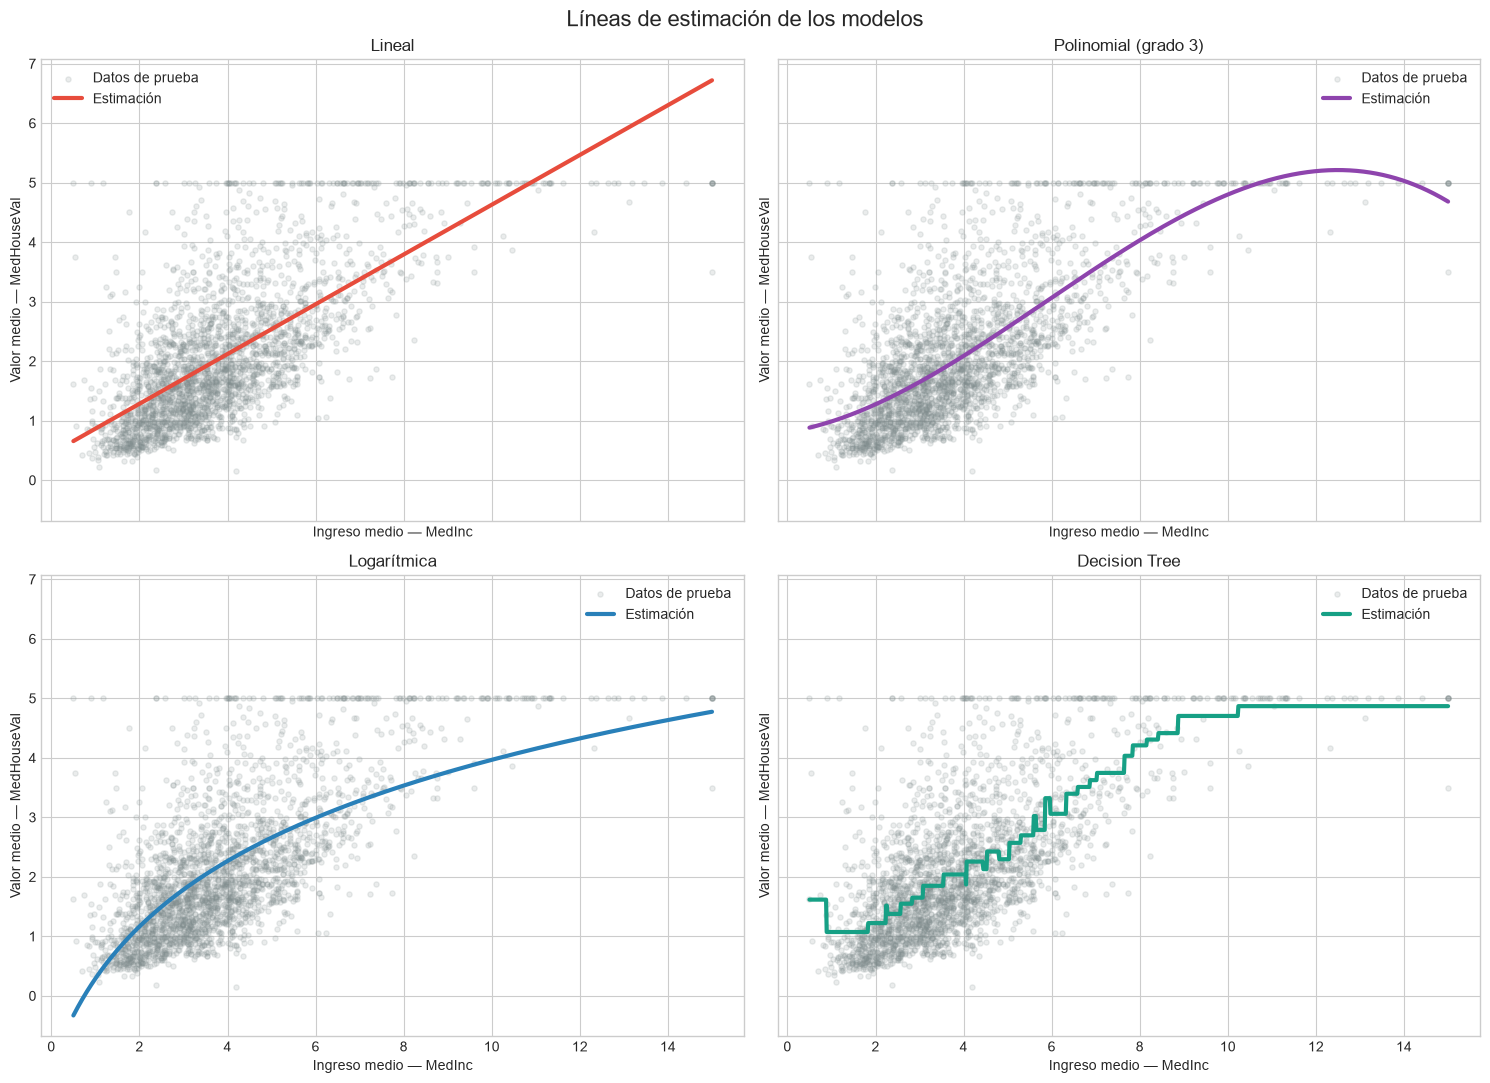

In [25]:
x_grid = np.linspace(X[:, 0].min(), X[:, 0].max(), 1000).reshape(-1, 1)
line_colors = {
    "Lineal": "#e74c3c",
    "Polinomial (grado 3)": "#8e44ad",
    "Logarítmica": "#2980b9",
    "Decision Tree": "#16a085",
}

plot_indices = np.random.default_rng(SEED).choice(
    len(X_test), size=min(2500, len(X_test)), replace=False
)

fig, axes = plt.subplots(2, 2, figsize=(15, 11), sharex=True, sharey=True)
for ax, (name, model) in zip(axes.ravel(), models.items()):
    ax.scatter(X_test[plot_indices, 0], y_test[plot_indices],
               color="#7f8c8d", alpha=0.16, s=14, label="Datos de prueba")
    ax.plot(x_grid[:, 0], model.predict(x_grid),
            color=line_colors[name], linewidth=3, label="Estimación")
    ax.set_title(name)
    ax.set_xlabel("Ingreso medio — MedInc")
    ax.set_ylabel("Valor medio — MedHouseVal")
    ax.legend()

plt.suptitle("Líneas de estimación de los modelos", fontsize=16)
plt.tight_layout()
plt.show()


### Comparación directa en una sola gráfica

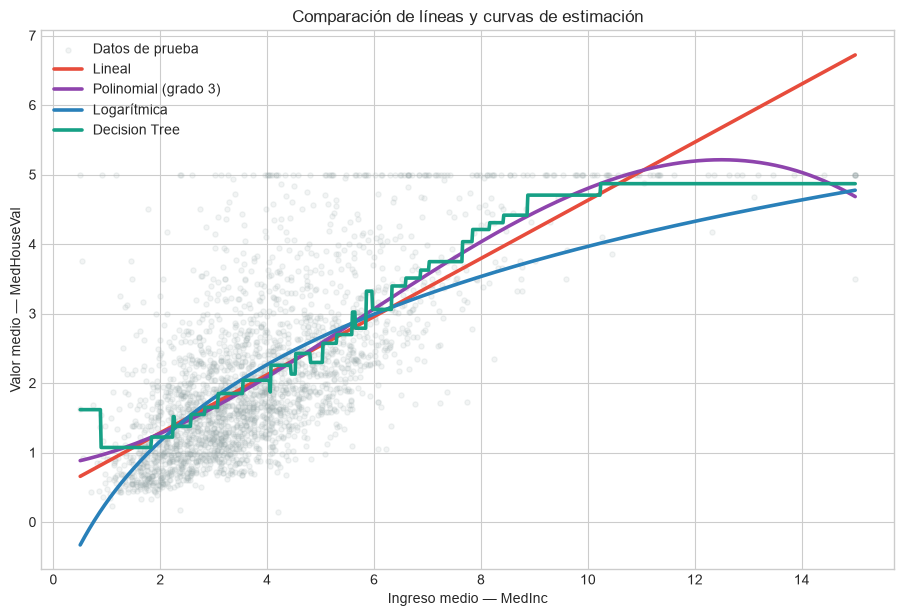

In [26]:
plt.figure(figsize=(11, 7))
plt.scatter(X_test[plot_indices, 0], y_test[plot_indices],
            color="#95a5a6", alpha=0.12, s=14, label="Datos de prueba")

for name, model in models.items():
    plt.plot(x_grid[:, 0], model.predict(x_grid),
             color=line_colors[name], linewidth=2.6, label=name)

plt.xlabel("Ingreso medio — MedInc")
plt.ylabel("Valor medio — MedHouseVal")
plt.title("Comparación de líneas y curvas de estimación")
plt.legend()
plt.show()


## 10. Valores reales contra estimados

Una predicción perfecta estaría sobre la línea diagonal negra. La dispersión alrededor de esta línea representa el error.

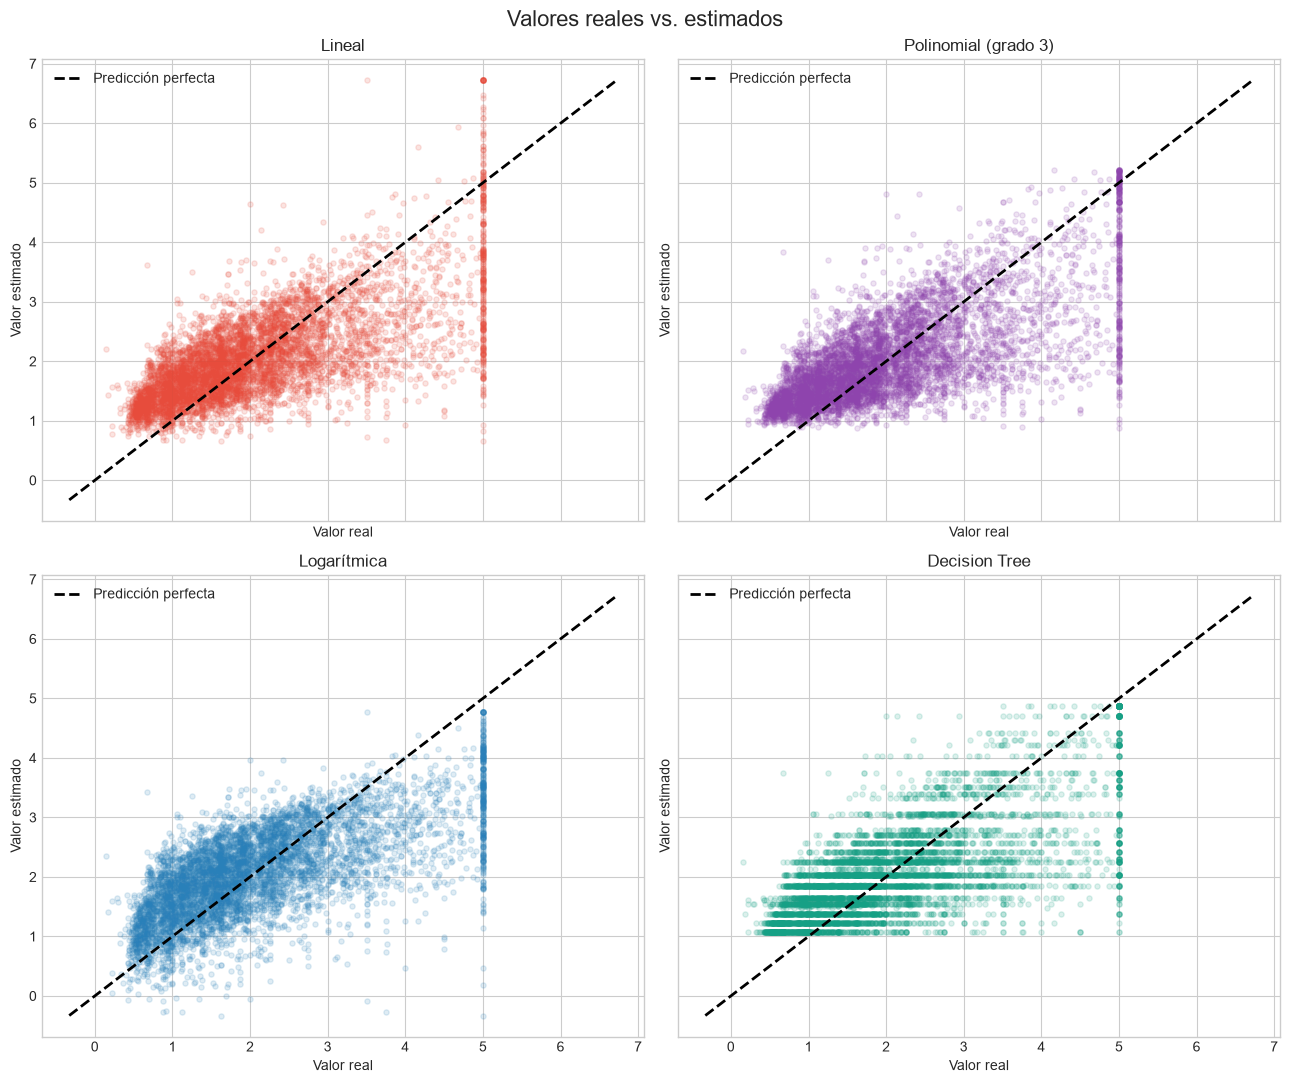

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11), sharex=True, sharey=True)
minimum = min(y_test.min(), *(pred.min() for pred in test_predictions.values()))
maximum = max(y_test.max(), *(pred.max() for pred in test_predictions.values()))

for ax, (name, prediction) in zip(axes.ravel(), test_predictions.items()):
    ax.scatter(y_test, prediction, alpha=0.15, s=14, color=line_colors[name])
    ax.plot([minimum, maximum], [minimum, maximum], "k--", linewidth=2,
            label="Predicción perfecta")
    ax.set_title(name)
    ax.set_xlabel("Valor real")
    ax.set_ylabel("Valor estimado")
    ax.legend()

plt.suptitle("Valores reales vs. estimados", fontsize=16)
plt.tight_layout()
plt.show()


## 11. Análisis de residuos

El residuo se define como `valor real - valor estimado`. Un buen modelo debería producir residuos repartidos alrededor de cero, sin un patrón sistemático.

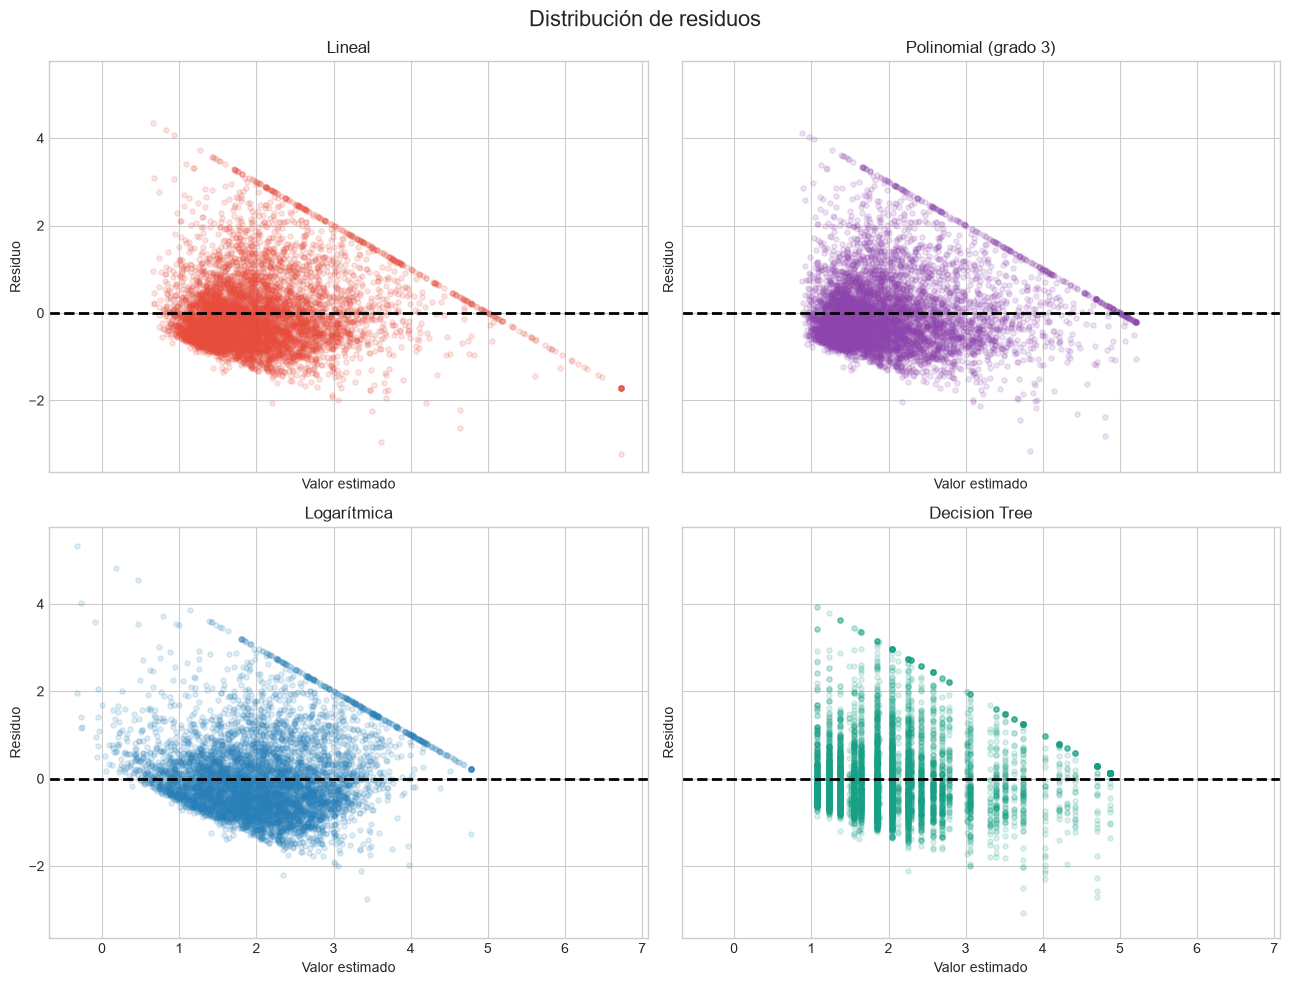

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=True, sharey=True)

for ax, (name, prediction) in zip(axes.ravel(), test_predictions.items()):
    residuals = y_test - prediction
    ax.scatter(prediction, residuals, alpha=0.15, s=14, color=line_colors[name])
    ax.axhline(0, color="black", linestyle="--", linewidth=2)
    ax.set_title(name)
    ax.set_xlabel("Valor estimado")
    ax.set_ylabel("Residuo")

plt.suptitle("Distribución de residuos", fontsize=16)
plt.tight_layout()
plt.show()


## 12. Estructura del árbol de decisión

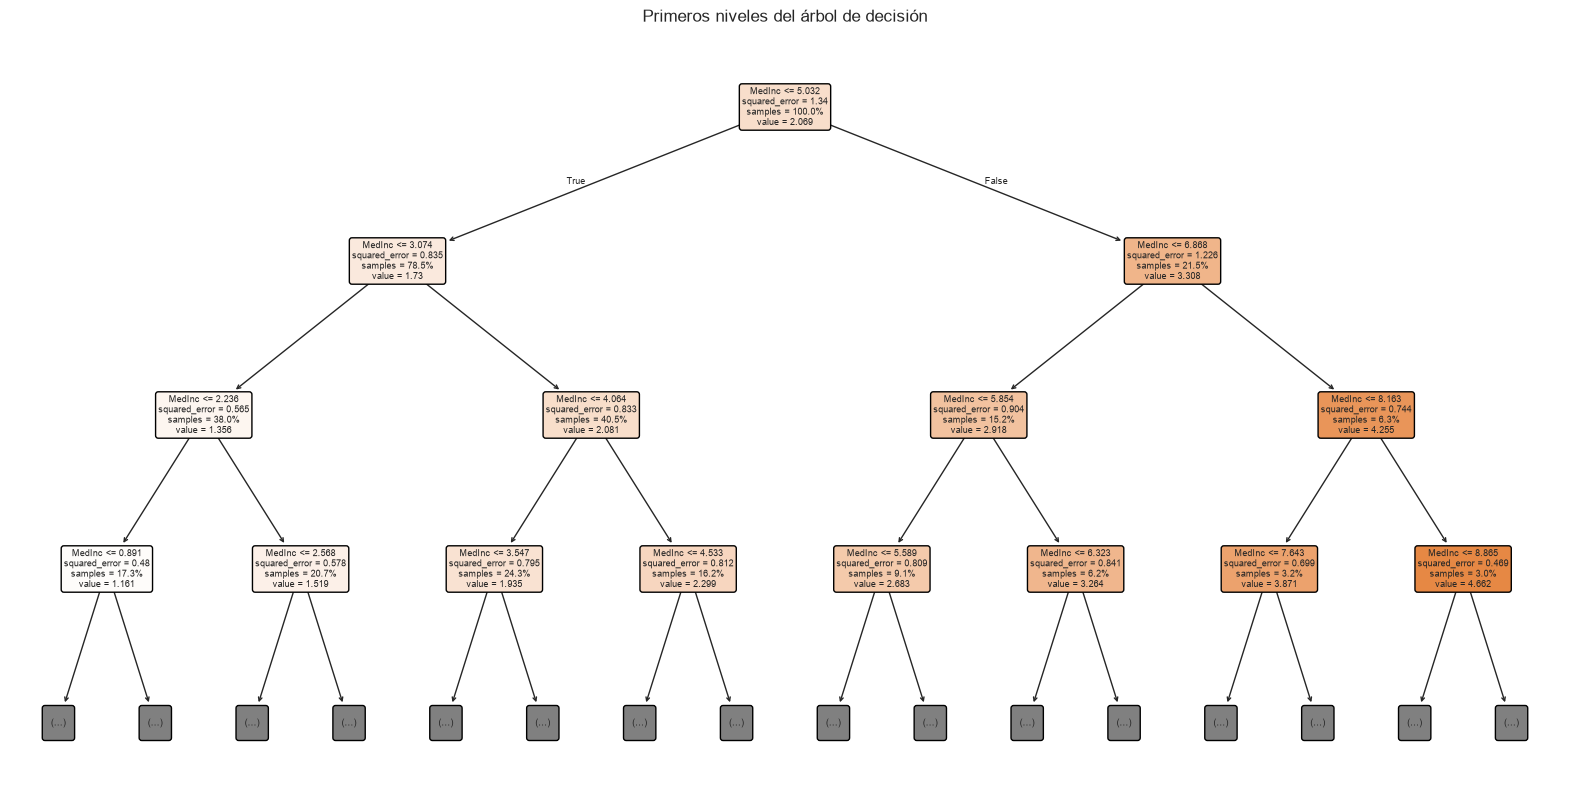

In [29]:
tree_model = models["Decision Tree"]

plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=["MedInc"],
    filled=True,
    rounded=True,
    proportion=True,
    precision=3,
    max_depth=3,
)
plt.title("Primeros niveles del árbol de decisión")
plt.show()


## 13. Selección final del modelo

La selección principal se realiza con el RMSE medio de validación cruzada. Después se presenta su rendimiento en el conjunto de prueba independiente.

In [30]:
best_cv_model = cv_metrics["RMSE media"].idxmin()

print("MODELO SELECCIONADO:", best_cv_model)
print(f"RMSE medio CV: {cv_metrics.loc[best_cv_model, 'RMSE media']:.4f}")
print(f"Desviación RMSE CV: {cv_metrics.loc[best_cv_model, 'RMSE std']:.4f}")
print(f"MAE en test: {test_metrics.loc[best_cv_model, 'MAE']:.4f}")
print(f"RMSE en test: {test_metrics.loc[best_cv_model, 'RMSE']:.4f}")
print(f"R² en test: {test_metrics.loc[best_cv_model, 'R²']:.4f}")


MODELO SELECCIONADO: Polinomial (grado 3)
RMSE medio CV: 0.8286
Desviación RMSE CV: 0.0183
MAE en test: 0.6155
RMSE en test: 0.8239
R² en test: 0.4828


## Conclusiones

1. La regresión lineal sirve como referencia sencilla, pero solo puede representar una tendencia recta.
2. La regresión polinomial captura curvatura, aunque grados altos pueden producir extrapolaciones inestables.
3. La regresión logarítmica representa crecimiento con rendimientos decrecientes.
4. El árbol de decisión captura relaciones no lineales mediante escalones, pero necesita restricciones para evitar sobreajuste.
5. La validación cruzada ofrece una comparación más confiable que una única partición de datos.
6. Utilizar una sola variable facilita interpretar las líneas de estimación, pero limita el R²: otras características de California Housing también influyen en el precio.
7. El conjunto de prueba se mantiene separado de la validación cruzada para obtener una evaluación final independiente.